In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
df = pd.read_csv('students_scores.csv')
df.head()

,Student_ID,Age,Math_Score,Science_Score,English_Score,Hours_Studied,Pass_Fail
0,S00001,22,85,64,62,4.7,1
1,S00002,19,73,78,74,3.1,1
2,S00003,20,86,85,81,6.4,1
3,S00004,22,90,91,93,9.9,1
4,S00005,18,76,65,71,4.2,1


##  Measures of Central Tendency & Dispersion

* Mean, Median, Mode of Math_Score


In [3]:
print('Mean:', df['Math_Score'].mean())
print('Median:', df['Math_Score'].median())
print('Mode:', df['Math_Score'].mode().tolist())

Mean: 75.424
Median: 76.0
Mode: [100]


* Range, Variance, Standard Deviation of Science_Score

In [4]:
science_range = df['Science_Score'].max() - df['Science_Score'].min()
science_variance = df['Science_Score'].var()
science_std = df['Science_Score'].std()

print('Range:', science_range)
print('Variance:', science_variance)
print('Standard Deviation:', science_std)

Range: 71
Variance: 218.98767657531505
Standard Deviation: 14.798232211156677


##  Probability Basics

* Probability of students passing

In [5]:
pass_probability = (df['Pass_Fail'] == 1).mean()
print('P(Pass):', pass_probability)

P(Pass): 0.9996


* Contingency Table

In [6]:
df['Studied_More_Than_5'] = df['Hours_Studied'] > 5
contingency = pd.crosstab(df['Pass_Fail'], df['Studied_More_Than_5'])
contingency

Studied_More_Than_5,False,True
Pass_Fail,,
0,2,0
1,2383,2615


* Conditional Probability P(Pass | Hours_Studied > 5)

In [7]:
conditional_prob = ((df['Pass_Fail'] == 1) & (df['Hours_Studied'] > 5)).sum() / (df['Hours_Studied'] > 5).sum()
print('P(Pass | Hours_Studied > 5):', conditional_prob)

P(Pass | Hours_Studied > 5): 1.0


##  Distribution & Visualization


* Histogram and Normal Curve for Math_Score

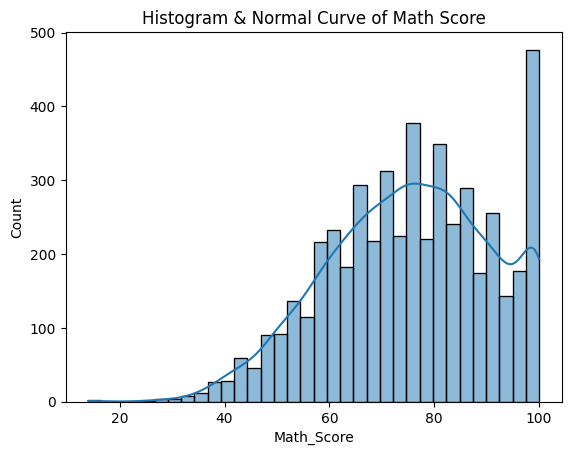

In [8]:
sns.histplot(df['Math_Score'], kde=True)
plt.title('Histogram & Normal Curve of Math Score')
plt.show()

📊 **Graph Insight — Histogram & Normal Curve (Math Score)**

The histogram shows the distribution of Math Scores across all students. The KDE (normal curve) overlaid on top reveals that the data is **slightly left-skewed** (skewness ≈ -0.28), meaning most students scored on the **higher side** — with a strong concentration between 60–100. The peak around 75–80 aligns with the mean of **75.42**, and the mode being **100** indicates a significant number of students scored full marks. The distribution is **platykurtic** (kurtosis ≈ -0.51), i.e., flatter than a perfect normal curve — scores are more spread out than expected.

* Skewness and Kurtosis of Science_Score

In [9]:
print('Skewness:', df['Science_Score'].skew())
print('Kurtosis:', df['Science_Score'].kurt())

Skewness: -0.2477302886188291
Kurtosis: -0.5207857123986783


* Q-Q Plot for English_Score

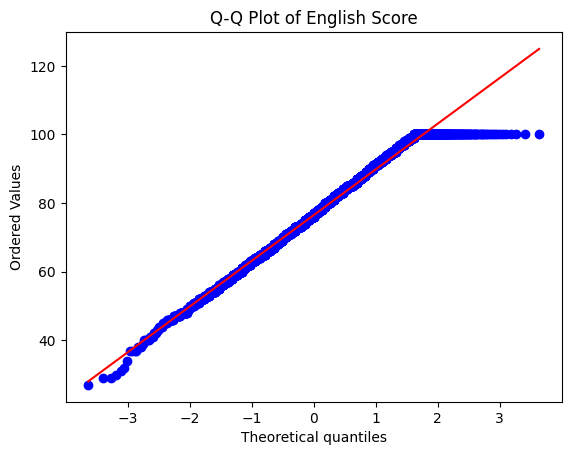

In [10]:

stats.probplot(df['English_Score'], dist='norm', plot=plt)
plt.title('Q-Q Plot of English Score')
plt.show()

📈 **Graph Insight — Q-Q Plot (English Score)**

A Q-Q (Quantile-Quantile) Plot is used to check whether the data follows a **normal distribution**. If the data points fall perfectly on the red diagonal line, the data is perfectly normal.

In this plot, the **middle portion** of the English Score data closely follows the red line, suggesting near-normality in the central range. However, both **tails deviate** — the lower tail dips below the line and the upper tail flattens (scores capping at 100), which is expected since exam scores have a natural ceiling. Overall, English Scores are **approximately normally distributed** in the central range.

## Linear Algebra Mini Task


* Vectors from first 5 students


In [11]:

math_vector = df['Math_Score'].head(5).values
science_vector = df['Science_Score'].head(5).values

print('Math Vector:', math_vector)
print('Science Vector:', science_vector)

Math Vector: [85 73 86 90 76]
Science Vector: [64 78 85 91 65]


* Dot Product

In [12]:
dot_product = np.dot(math_vector, science_vector)
print('Dot Product:', dot_product)

Dot Product: 31574


* Norm 1 and Norm 2 of Math Vector

In [13]:
norm1 = np.linalg.norm(math_vector, ord=1)
norm2 = np.linalg.norm(math_vector, ord=2)
print('Norm 1:', norm1)
print('Norm 2:', norm2)

Norm 1: 410.0
Norm 2: 183.91846019364124


* Angle Between Vectors

In [15]:
cos_theta = np.dot(math_vector, science_vector) / (np.linalg.norm(math_vector) * np.linalg.norm(science_vector))
angle = np.degrees(np.arccos(cos_theta))
print('Angle Between Vectors (degrees):', angle)

Angle Between Vectors (degrees): 6.958934437133269
